## 1. Định nghĩa Vấn đề
**Mô tả**
Bộ dữ liệu housing (Boston-style) gồm các mẫu đại diện cho các khu vực địa phương; mỗi mẫu chứa các đặc trưng về điều kiện kinh tế, hạ tầng và đặc tính nhà ở. Mục tiêu là dự đoán giá nhà trung vị của từng khu vực dựa trên các đặc trưng này. File dữ liệu trong dự án: housing.csv.
**Dữ liệu vào (Features)**

+ CRIM — Tỷ lệ tội phạm theo khu vực
+ ZN — Tỷ lệ đất dành cho khu dân cư >25.000 sq.ft
+ INDUS — Tỷ lệ diện tích thương mại/phi bán lẻ (%)
+ CHAS — Biến chỉ số sông Charles (1 nếu giáp sông, 0 nếu không)
+ NOX — Nồng độ NOx (phần triệu)
+ RM — Số phòng trung bình trên mỗi cư trú
+ AGE — Tỷ lệ nhà xây trước năm 1940 (%)
+ DIS — Khoảng cách đến các trung tâm lao động (trọng số)
+ RAD — Chỉ số tiếp cận đường vành đai/xa lộ
+ TAX — Thuế tài sản hàng năm (trên 10.000$)
+ PTRATIO — Tỉ lệ học sinh/giáo viên
+ B — 1000(Bk - 0.63)^2 (chỉ số dân cư)
+ LSTAT — % dân có thu nhập thấp

**Kết quả / Mục tiêu (Target / Goal)**

+ MEDV — Giá nhà trung vị (median value) — bài toán hồi quy (dự đoán giá liên tục).

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1 Tải thư viện

In [1]:
# Load libraries
import numpy
import pandas as pd
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

### 2.1. Nạp dữ liệu (Load Dataset)

In [2]:
# Load dataset
filename = '../data/raw/housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(filename, names=names, index_col=0)

## 3. Phân tích khám phá dữ liệu (Exploration Analyze Data - EDA)

### 3.1 Thống kê mô tả

In [3]:
# shape
print(dataset.shape)

(506, 14)


In [4]:
# types
print(dataset.dtypes)

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


In [5]:
# head
print(dataset.head(20))

       CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD  TAX  \
1   0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296   
2   0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242   
3   0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242   
4   0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222   
5   0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222   
6   0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222   
7   0.08829  12.5   7.87     0  0.524  6.012   66.6  5.5605    5  311   
8   0.14455  12.5   7.87     0  0.524  6.172   96.1  5.9505    5  311   
9   0.21124  12.5   7.87     0  0.524  5.631  100.0  6.0821    5  311   
10  0.17004  12.5   7.87     0  0.524  6.004   85.9  6.5921    5  311   
11  0.22489  12.5   7.87     0  0.524  6.377   94.3  6.3467    5  311   
12  0.11747  12.5   7.87     0  0.524  6.009   82.9  6.2267    5  311   
13  0.09378  12.5   7.87     0  0.524  5.889   39.0

+ Dữ liệu có 13 đặc trưng đầu vào: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT.
+ Các đặc trưng đo khác đơn vị — có tỷ lệ (CRIM, INDUS, LSTAT, ...), phần trăm (AGE, LSTAT), chỉ số/score (RAD, B), số trung bình (RM) và giá trị khảo sát (TAX, PTRATIO). Không phải tất cả đều cùng đơn vị.
+ Cột mục tiêu là MEDV (median value) — giá nhà trung vị (bài toán hồi quy).
+ Tổng số dòng dữ liệu: kiểm tra bằng dataset.shape có 506 dòng.

In [6]:
# descriptions
set_option('display.precision', 1)
print(dataset.describe())

          CRIM     ZN  INDUS     CHAS    NOX     RM    AGE    DIS    RAD  \
count  5.1e+02  506.0  506.0  5.1e+02  506.0  506.0  506.0  506.0  506.0   
mean   3.6e+00   11.4   11.1  6.9e-02    0.6    6.3   68.6    3.8    9.5   
std    8.6e+00   23.3    6.9  2.5e-01    0.1    0.7   28.1    2.1    8.7   
min    6.3e-03    0.0    0.5  0.0e+00    0.4    3.6    2.9    1.1    1.0   
25%    8.2e-02    0.0    5.2  0.0e+00    0.4    5.9   45.0    2.1    4.0   
50%    2.6e-01    0.0    9.7  0.0e+00    0.5    6.2   77.5    3.2    5.0   
75%    3.7e+00   12.5   18.1  0.0e+00    0.6    6.6   94.1    5.2   24.0   
max    8.9e+01  100.0   27.7  1.0e+00    0.9    8.8  100.0   12.1   24.0   

         TAX  PTRATIO      B  LSTAT   MEDV  
count  506.0    506.0  506.0  506.0  506.0  
mean   408.2     18.5  356.7   12.7   22.5  
std    168.5      2.2   91.3    7.1    9.2  
min    187.0     12.6    0.3    1.7    5.0  
25%    279.0     17.4  375.4    6.9   17.0  
50%    330.0     19.1  391.4   11.4   21.2  


In [7]:
# correlation
set_option('display.precision', 2)
print(dataset.corr(method='pearson'))

         CRIM    ZN  INDUS      CHAS   NOX    RM   AGE   DIS       RAD   TAX  \
CRIM     1.00 -0.20   0.41 -5.59e-02  0.42 -0.22  0.35 -0.38  6.26e-01  0.58   
ZN      -0.20  1.00  -0.53 -4.27e-02 -0.52  0.31 -0.57  0.66 -3.12e-01 -0.31   
INDUS    0.41 -0.53   1.00  6.29e-02  0.76 -0.39  0.64 -0.71  5.95e-01  0.72   
CHAS    -0.06 -0.04   0.06  1.00e+00  0.09  0.09  0.09 -0.10 -7.37e-03 -0.04   
NOX      0.42 -0.52   0.76  9.12e-02  1.00 -0.30  0.73 -0.77  6.11e-01  0.67   
RM      -0.22  0.31  -0.39  9.13e-02 -0.30  1.00 -0.24  0.21 -2.10e-01 -0.29   
AGE      0.35 -0.57   0.64  8.65e-02  0.73 -0.24  1.00 -0.75  4.56e-01  0.51   
DIS     -0.38  0.66  -0.71 -9.92e-02 -0.77  0.21 -0.75  1.00 -4.95e-01 -0.53   
RAD      0.63 -0.31   0.60 -7.37e-03  0.61 -0.21  0.46 -0.49  1.00e+00  0.91   
TAX      0.58 -0.31   0.72 -3.56e-02  0.67 -0.29  0.51 -0.53  9.10e-01  1.00   
PTRATIO  0.29 -0.39   0.38 -1.22e-01  0.19 -0.36  0.26 -0.23  4.65e-01  0.46   
B       -0.39  0.18  -0.36  4.88e-02 -0.

### 3.2 Trực quan hóa dữ liệu

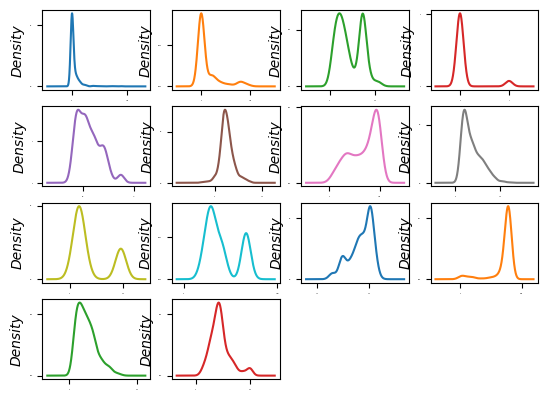

In [8]:
# density
dataset.plot(kind='density', subplots=True, layout=(4,4), sharex=False, legend=False,
fontsize=1)
pyplot.show()

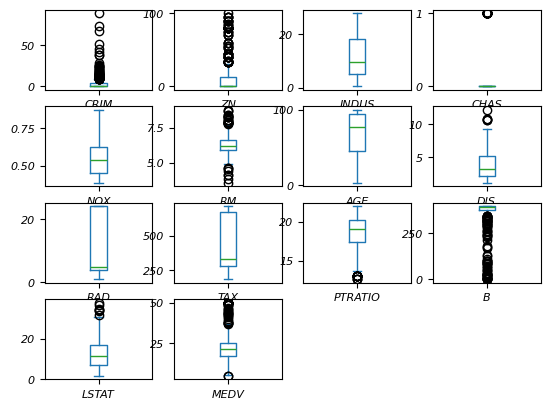

In [9]:
# box and whisker plots
dataset.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False,
fontsize=8)
pyplot.show()

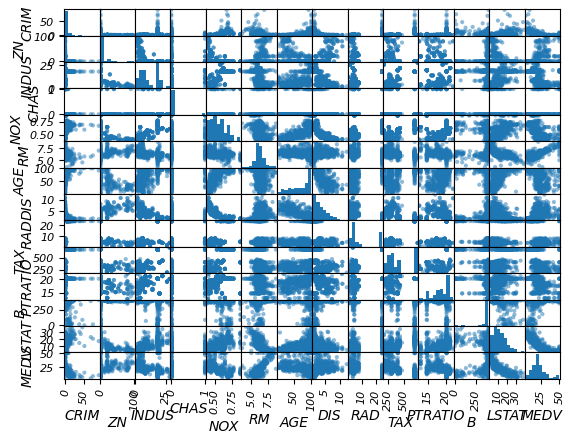

In [10]:
# scatter plot matrix
scatter_matrix(dataset)
pyplot.show()

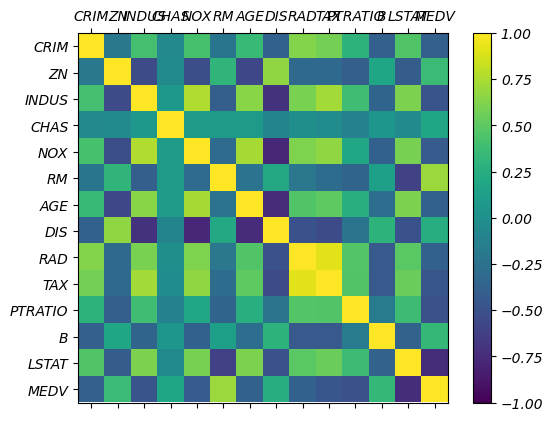

In [12]:
# correlation matrix
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(dataset.corr(), vmin=-1, vmax=1, interpolation='none')
fig.colorbar(cax)
ticks = numpy.arange(0,14,1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
pyplot.show()

In [13]:
!rm $cur_dir/eda.html
!jupyter nbconvert $cur_dir/eda.ipynb --to html

'rm' is not recognized as an internal or external command,
operable program or batch file.


This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr

[NbConvertApp] WARNING | pattern '$cur_dir/eda.ipynb' matched no files


## 4. Lưu tất cả hình ảnh

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from save_images import save_notebook_images, print_save_summary

# Lưu tất cả hình ảnh từ notebook
result = save_notebook_images("EDA.ipynb", output_dir="images")

# In tóm tắt kết quả
print_save_summary(result)



✅ Hoàn tất: 4 hình ảnh được lưu
📁 Thư mục: c:\Users\ASUS\Documents\SGU_khai_pha_du_lieu_DDU1231\Thực hành\Housing_project\EDA\images
📋 Danh sách file:
   - images\density_plot_01.png
   - images\box_plot_02.png
   - images\scatter_plot_matrix_03.png
   - images\correlation_matrix_04.png
